In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from scoreoperator.utils.data import DataFactory
from scoreoperator.neuralop.uno import ModelFactory
from scoreoperator.utils.configs import load_ellipse_cylindrical_brownian_config
from scoreoperator.diffusion.bridge import DiffusionBridge
from scoreoperator.utils.trainer import ScoreModel

In [19]:
config = load_ellipse_cylindrical_brownian_config()

s0 = DataFactory.create(
    "ellipse",
    {
        "a": 1.25,
        "b": 0.85,
        "shift_x": 0.0,
        "shift_y": 0.0
    }
)
sT = DataFactory.create(
    "ellipse",
    {
        "a": 1.5,
        "b": 0.5,
        "shift_x": 0.0,
        "shift_y": 0.0
    }
)

db = DiffusionBridge(config.sde_type, config.sde_config)
model = ModelFactory.create(config.model_type, config.model_config)

score_model = ScoreModel(
    model, 
    "../ckpts/ellipse_cylindrical_brownian",
)
# score_model = lambda t, x: - x / t

rng_key = jr.PRNGKey(config.train_config.seed)

/opt/homebrew/Caskroom/miniconda/base/envs/scoreoperator/lib/python3.10/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


In [20]:
x_shape = (16, 2)
t_shape = (100, )
w_shape = (16, 2)

ys = db.solve_reverse_bridge(rng_key, score_model, x_shape, t_shape, w_shape)

ys = ys + s0.eval(x_shape)
print(ys.shape)

(101, 16, 2)


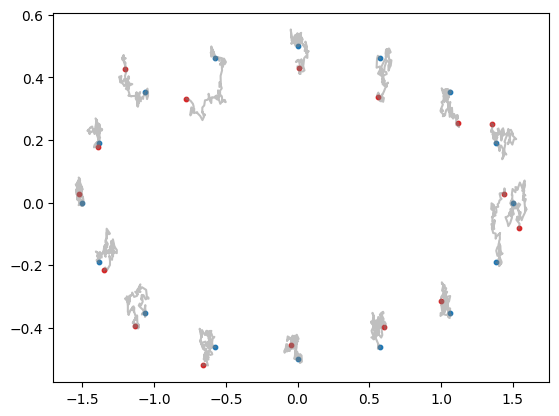

In [21]:
fig = plt.figure()

plt.scatter(ys[0, :, 0], ys[0, :, 1], color="tab:blue", s=10)

for i in range(ys.shape[1]):
    plt.plot(ys[:, i, 0], ys[:, i, 1], color="grey", alpha=0.5)
    
plt.scatter(ys[-1, :, 0], ys[-1, :, 1], color="tab:red", s=10)